In [1]:
import matplotlib.pyplot as plt
from factor_diffusion_sample import generate_rejection, _tcfg
import matplotlib.patches as mpatches
from matplotlib.colors import TwoSlopeNorm
import matplotlib.gridspec as gridspec
from factor_model import *
from sklearn.decomposition import PCA
from scipy.stats import gaussian_kde
import os
from scenario_generator import *

/home/renyi/anaconda3/envs/diffusion_factor_model/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def plot_vol_panel(ax, xlim, title_suffix, datasets, fidx, threshold=None):
    for label, data, color in datasets:
        col     = data[:, fidx] if data.ndim == 2 else data
        clipped = col[(col >= xlim[0]) & (col <= xlim[1])]
        if len(clipped) < 2:
            continue
        ax.hist(clipped, bins=40, density=True, alpha=0.55,
                color=color, label=label, edgecolor="white", linewidth=0.4)
        kde = gaussian_kde(col, bw_method=0.3)
        x_grid = np.linspace(xlim[0], xlim[1], 400)
        ax.plot(x_grid, kde(x_grid), color=color, linewidth=2)

    if threshold is not None:
        ax.axvline(threshold, color="black", linestyle="--", linewidth=1.5,
                   label=f"threshold = {threshold:.4f}")
    ax.set_xlabel(FACTOR_NAMES[fidx])
    ax.set_ylabel("density")
    ax.set_xlim(xlim)
    ax.set_title(title_suffix)
    ax.legend(fontsize=8, framealpha=0.9)
    for i, (label, data, color) in enumerate(datasets):
        col     = data[:, fidx] if data.ndim == 2 else data
        pct     = (col <= threshold).mean() * 100 if threshold is not None else float("nan")
        visible = ((col >= xlim[0]) & (col <= xlim[1])).sum()
        ax.text(0.02, 0.97 - i * 0.10,
                f"{label}: {pct:.0f}% <= thr  ({visible}/{len(col)} visible)",
                transform=ax.transAxes, fontsize=8,
                color=color, va="top")

-  max is increasing via sample size and it is not stable in market factor
- N = 4096 other fatcor are stable

In [3]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_TIMESTEPS = _tcfg["num_timesteps"]
LEVY_ALPHA    = _tcfg["levy_alpha"]
PREFIX        = _tcfg["prefix"]
BATCH_SIZE    = _tcfg["batch_size"]
FACTOR_NAMES  = _tcfg["factor_names"]
FACTOR_DIM    = len(_tcfg["factor_names"])
CHECKPOINT    = f"{PREFIX}/checkpoints/factor_DLPM_ep0200.pt"

In [4]:
# util functions
def _to_norm(scaler, value, idx):
    dummy = np.zeros((1, FACTOR_DIM))
    dummy[0, idx] = value
    return float(scaler.transform(dummy)[0, idx])

def make_cond_fn(interval, scaler, feature_idx=0, normalize=True):
    thl, thr = interval

    if normalize:
        qmin_norm = _to_norm(scaler, thl, feature_idx)
        qmax_norm = _to_norm(scaler, thr, feature_idx)

        def cond_fn(x0_hat):
            return (torch.relu(x0_hat[:, feature_idx] - qmax_norm) +
                    torch.relu(qmin_norm - x0_hat[:, feature_idx]))
    else:
        def cond_fn(x0_hat):
            return (torch.relu(x0_hat[:, feature_idx] - thr) +
                    torch.relu(thl - x0_hat[:, feature_idx]))

    cond_fn.label = f"{FACTOR_NAMES[feature_idx]} between [{thl:.4f}, {thr:.4f}]"

    return cond_fn

In [5]:
# load achievements
"""
ckpt = torch.load(CHECKPOINT, map_location=DEVICE, weights_only=False)
model = FactorDenoiser(**ckpt["model_kwargs"]).to(DEVICE)
model.load_state_dict(ckpt["model_state"])
gammas, bargammas, sigmas, barsigmas = levy_noise_schedule(LEVY_ALPHA, NUM_TIMESTEPS)
scaler = ckpt["scaler"]
args   = (model, gammas, bargammas, sigmas, barsigmas, LEVY_ALPHA, scaler)

"""

'\nckpt = torch.load(CHECKPOINT, map_location=DEVICE, weights_only=False)\nmodel = FactorDenoiser(**ckpt["model_kwargs"]).to(DEVICE)\nmodel.load_state_dict(ckpt["model_state"])\ngammas, bargammas, sigmas, barsigmas = levy_noise_schedule(LEVY_ALPHA, NUM_TIMESTEPS)\nscaler = ckpt["scaler"]\nargs   = (model, gammas, bargammas, sigmas, barsigmas, LEVY_ALPHA, scaler)\n\n'

In [6]:
"""
Ns = [128, 256, 512, 1028, 2048, 4096, 10000]
uncons = [generate(*args, num_samples=N) for N in Ns]
maxns = [np.max(uncon[0], axis=0) for uncon in uncons]
maxns
q3s   = [np.percentile(uncon[0], 3, axis=0) for uncon in uncons]
qmins = [uncon[0].min(axis=0) for uncon in uncons]
fidx  = FACTOR_NAMES.index("momentum")
conds = []
for q3, qmin in zip(q3s, qmins):
    cond = make_cond_fn((qmin[fidx], q3[fidx]), scaler, fidx)
    conds.append(cond)

cons  = [generate(*args, cond_fn=c, guidance_scale=GUIDANCE_S, num_samples=n)
         for c, n in zip(conds, Ns)]
maxns = [np.max(con[0], axis) for con in cons]
maxns
"""

'\nNs = [128, 256, 512, 1028, 2048, 4096, 10000]\nuncons = [generate(*args, num_samples=N) for N in Ns]\nmaxns = [np.max(uncon[0], axis=0) for uncon in uncons]\nmaxns\nq3s   = [np.percentile(uncon[0], 3, axis=0) for uncon in uncons]\nqmins = [uncon[0].min(axis=0) for uncon in uncons]\nfidx  = FACTOR_NAMES.index("momentum")\nconds = []\nfor q3, qmin in zip(q3s, qmins):\n    cond = make_cond_fn((qmin[fidx], q3[fidx]), scaler, fidx)\n    conds.append(cond)\n\ncons  = [generate(*args, cond_fn=c, guidance_scale=GUIDANCE_S, num_samples=n)\n         for c, n in zip(conds, Ns)]\nmaxns = [np.max(con[0], axis) for con in cons]\nmaxns\n'

In [7]:
# unconditional sample and conditional config
GUIDANCE_S = 5 # guidance scale
N = 4096 # sample number
train_model = load_model(f"{PREFIX}")
diffusionScenario = ScenarioGenerator(train_model, DiffusionSampler(CHECKPOINT, guidance_scale = GUIDANCE_S))
uncon = diffusionScenario.factor_generate(N)
uncon.shape

(4096, 7)

In [8]:
#momentum < 3% quantile
q3   = np.percentile(uncon, 3,  axis=0)
qmin = uncon.min(axis=0)
fidx = FACTOR_NAMES.index("momentum")

lower003_fn  = make_cond_fn((qmin[fidx], q3[fidx]), diffusionScenario.sampler.scaler, fidx)
lower003 = diffusionScenario.cond_factor_generate(N, lower003_fn)
print(lower003_fn.label)

momentum between [-0.0175, -0.0047]


In [9]:
REJ_CACHE = f"{PREFIX}/samples/rej_momentum_bottom3pct_N{N}_s{GUIDANCE_S}_norm.npy"

if os.path.exists(REJ_CACHE):
    rej = np.load(REJ_CACHE)
    print(f"Loaded cached rej samples from {REJ_CACHE}  shape={rej.shape}")
else:
    print("Cache not found, running rejection sampling (slow)...")
    rej = generate_rejection(diffusionScenario.sampler.model, diffusionScenario.sampler.scaler, cond_fn=lower003_fn,
                             num_samples=N, guidance_scale=GUIDANCE_S)
    np.save(REJ_CACHE, rej)
    print(f"Saved to {REJ_CACHE}  shape={rej.shape}")

Cache not found, running rejection sampling (slow)...
  [rejection] accepted 4096/145792  (rate=0.0281)
Saved to model/regression/samples/rej_momentum_bottom3pct_N4096_s5_norm.npy  shape=(4096, 7)


In [10]:
COLORS = {
    "uncon":  "#888888",
    "con":    "#2196F3",
}
datasets = [
    ("uncon", uncon,    COLORS["uncon"]),
    ("con",   lower003, COLORS["con"]),
]

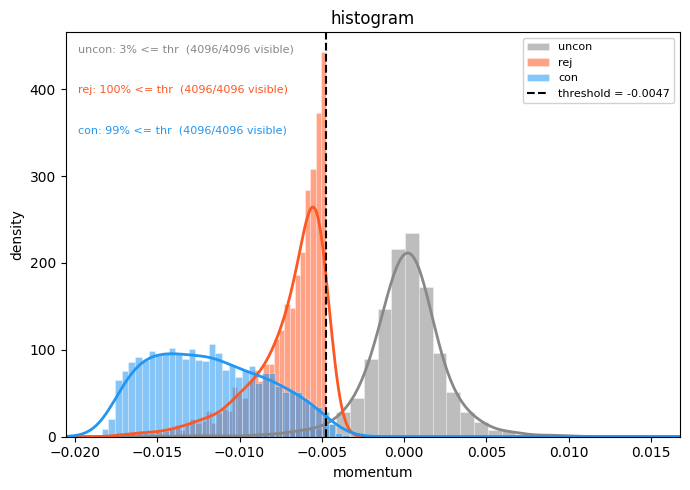

In [11]:
datasets_hist = [
    ("uncon", uncon,    COLORS["uncon"]),
    ("rej",   rej,      "#FF5722"),
    ("con",   lower003, COLORS["con"]),
]
all_data = np.concatenate([d[:, fidx] for _, d, _ in datasets_hist])
full_lim = (all_data.min() - abs(all_data.min()) * 0.05,
            all_data.max() + abs(all_data.max()) * 0.05)
fig2, ax_full = plt.subplots(figsize=(7, 5))
plot_vol_panel(ax_full, full_lim, "histogram", datasets_hist, fidx=fidx, threshold=q3[fidx])
fig2.tight_layout()
plt.show()

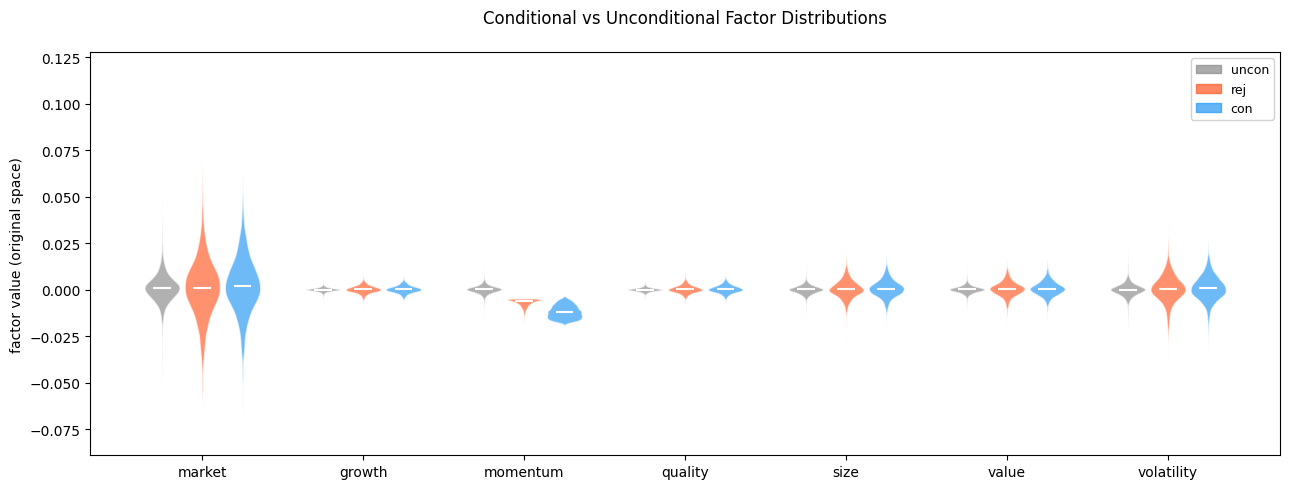

In [12]:
datasets = [
    ("uncon", uncon,    COLORS["uncon"]),
    ("rej",   rej,      "#FF5722"),
    ("con",   lower003, COLORS["con"]),
]
x_center = np.arange(FACTOR_DIM)
offsets  = [-0.25, 0.0, 0.25]
fig, ax = plt.subplots(figsize=(13, 5))

for offset, (label, data, color) in zip(offsets, datasets):
    parts = ax.violinplot(
        [data[:, i] for i in range(FACTOR_DIM)],
        positions=x_center + offset,
        widths=0.22,
        showmedians=True,
        showextrema=False,
    )
    for pc in parts["bodies"]:
        pc.set_facecolor(color)
        pc.set_edgecolor("white")
        pc.set_alpha(0.65)
    parts["cmedians"].set_color("white")
    parts["cmedians"].set_linewidth(1.5)

ax.set_xticks(x_center)
ax.set_xticklabels(FACTOR_NAMES, fontsize=10)
ax.set_ylabel("factor value (original space)")
ax.set_title(
    f"Conditional vs Unconditional Factor Distributions\n"
)

handles = [mpatches.Patch(color=c, alpha=0.7, label=l) for l, _, c in datasets]
ax.legend(handles=handles, fontsize=9, framealpha=0.9)

fig.tight_layout()
plt.show()

### Correlation Heatmaps - Unconditional vs Conditional

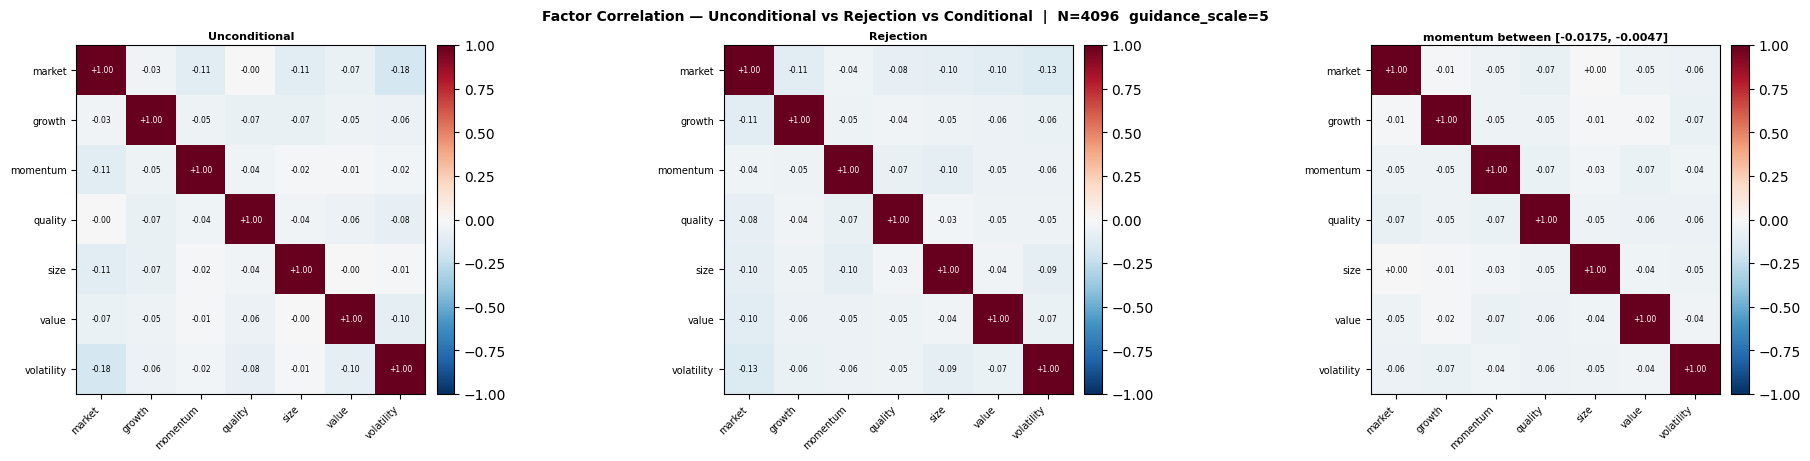

In [13]:

def corr_mat(data):
    return np.corrcoef(data, rowvar=False)

corr_uncon = corr_mat(uncon)
corr_rej   = corr_mat(rej)
corr_low   = corr_mat(lower003)
corr_diff  = corr_low - corr_uncon

panels = [
    ("Unconditional",    corr_uncon, TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1), "RdBu_r"),
    ("Rejection",        corr_rej,   TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1), "RdBu_r"),
    (lower003_fn.label,  corr_low,   TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1), "RdBu_r"),
]

fig = plt.figure(figsize=(18, 4.5), layout="constrained")
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.25)

for idx, (name, corr, norm, cmap) in enumerate(panels):
    ax = fig.add_subplot(gs[idx])
    im = ax.imshow(corr, cmap=cmap, norm=norm, aspect="equal")
    ax.set_xticks(range(FACTOR_DIM))
    ax.set_yticks(range(FACTOR_DIM))
    ax.set_xticklabels(FACTOR_NAMES, rotation=45, ha="right", fontsize=7)
    ax.set_yticklabels(FACTOR_NAMES, fontsize=7)
    ax.set_title(name, fontweight="bold", fontsize=8, pad=4)
    for ii in range(FACTOR_DIM):
        for jj in range(FACTOR_DIM):
            ax.text(jj, ii, f"{corr[ii,jj]:+.2f}",
                    ha="center", va="center", fontsize=5.5,
                    color="white" if abs(corr[ii,jj]) > 0.4 else "black")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.03)

fig.suptitle(
    f"Factor Correlation — Unconditional vs Rejection vs Conditional  |  N={N}  guidance_scale={GUIDANCE_S}",
    fontsize=10, fontweight="bold"
)
plt.show()

In [14]:
mask = np.triu(np.ones((FACTOR_DIM, FACTOR_DIM), dtype=bool), k=1)
diff_vals  = corr_rej[mask]
corr_diff_rej  = corr_low - corr_uncon
print(f"Mean Δcorr diffusion guidance: {diff_vals.mean():+.4f}")
print(f"Mean Δcorr rejection sampling: {corr_diff_rej.mean():+.4f}")

Mean Δcorr diffusion guidance: -0.0688
Mean Δcorr rejection sampling: +0.0093


In [15]:
# --- load historical factor data ---
hist = pd.read_csv(f"{PREFIX}/factors.csv", index_col=0, parse_dates=True)
# drop alpha column if present
hist = hist[[c for c in hist.columns if c in FACTOR_NAMES]]
hist = hist[FACTOR_NAMES]   # align column order

# --- filter historical days matching condition: momentum < q3[fidx] ---
mom_thresh = q3[fidx]       # same threshold used to generate lower003
hist_stress = hist[hist.iloc[:, fidx] < mom_thresh].values
gen_stress  = lower003      # (N, FACTOR_DIM)

print(f"Historical stress days:  {len(hist_stress)}")
print(f"Generated stress samples: {len(gen_stress)}")
print(f"Momentum threshold: {mom_thresh:.4f}")

Historical stress days:  190
Generated stress samples: 4096
Momentum threshold: -0.0047


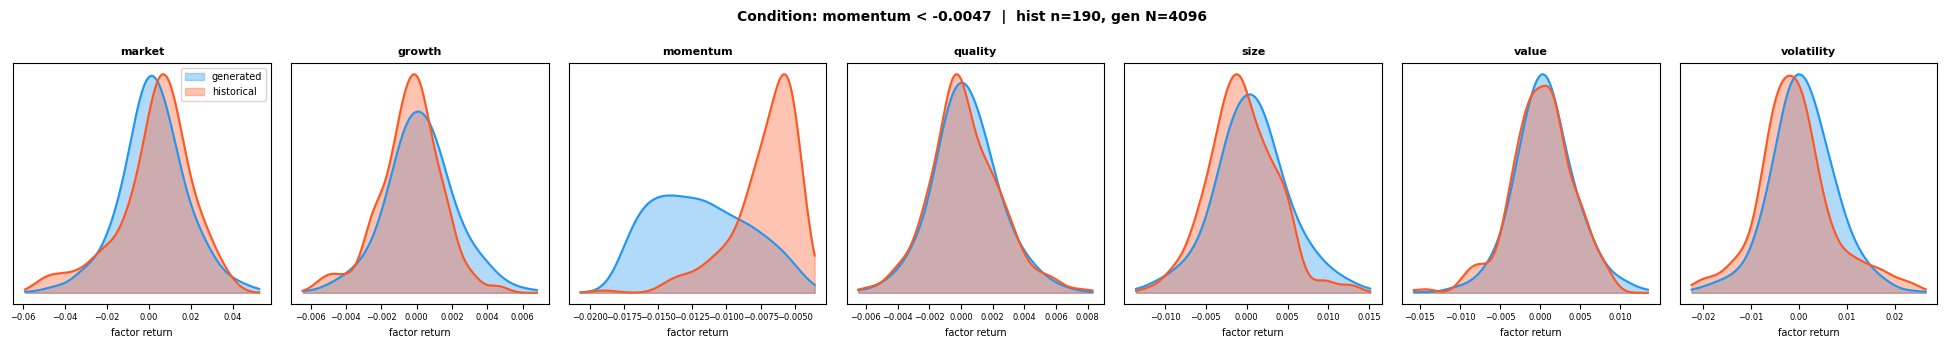

In [16]:
ncols = FACTOR_DIM
fig, axes = plt.subplots(1, ncols, figsize=(ncols * 2.8, 3.5))

for i, (ax, name) in enumerate(zip(axes, FACTOR_NAMES)):
    gen_col  = gen_stress[:, i]
    hist_col = hist_stress[:, i]

    # common x range: envelope both
    xlo = min(np.percentile(gen_col, 0.5), np.percentile(hist_col, 0.5))
    xhi = max(np.percentile(gen_col, 99.5), np.percentile(hist_col, 99.5))
    xlo -= (xhi - xlo) * 0.05
    xhi += (xhi - xlo) * 0.05
    x_grid = np.linspace(xlo, xhi, 400)

    kde_gen  = gaussian_kde(gen_col,  bw_method=0.3)
    kde_hist = gaussian_kde(hist_col, bw_method=0.3)

    ax.fill_between(x_grid, kde_gen(x_grid),  alpha=0.35, color="#2196F3", label="generated")
    ax.fill_between(x_grid, kde_hist(x_grid), alpha=0.35, color="#FF5722", label="historical")
    ax.plot(x_grid, kde_gen(x_grid),  color="#2196F3", linewidth=1.5)
    ax.plot(x_grid, kde_hist(x_grid), color="#FF5722", linewidth=1.5)

    ax.set_title(name, fontsize=8, fontweight="bold")
    ax.set_xlabel("factor return", fontsize=7)
    ax.tick_params(labelsize=6)
    ax.set_yticks([])

    if i == 0:
        ax.legend(fontsize=7, framealpha=0.8)

fig.suptitle(
    f"Condition: momentum < {mom_thresh:.4f}  |  hist n={len(hist_stress)}, gen N={len(gen_stress)}",
    fontsize=10, fontweight="bold"
)
plt.tight_layout()
plt.show()

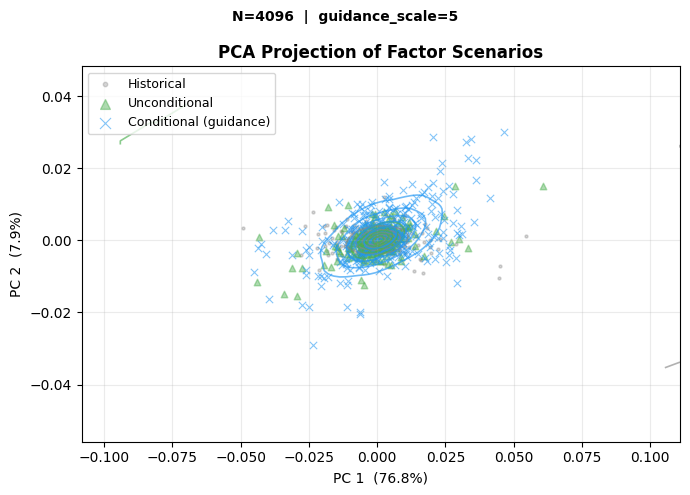

In [17]:
# TAT
from factor_model import load_model, reconstruct_returns

# --- load factor model ---
train_model = load_model(f"{PREFIX}")

# --- generated stress stock returns ---
fs_gen = np.column_stack([
    np.ones((len(lower003), 1), dtype=np.float32),
    lower003.astype(np.float32),
])
R_gen_stress = reconstruct_returns(train_model, fs_gen)   # (N, S)

# --- historical stock returns on stress days ---
stress_mask   = train_model.F["momentum"].values < q3[fidx]
fs_hist       = train_model.F.values[stress_mask].astype(np.float32)
R_hist_stress = reconstruct_returns(train_model, fs_hist)  # (T_stress, S)


train_vals = hist.values  # (T, 7)

pca = PCA(n_components=2)
pca.fit(train_vals)

train_pc = pca.transform(train_vals)
uncon_pc = pca.transform(uncon)
con_pc   = pca.transform(lower003)

xlab = f"PC 1  ({pca.explained_variance_ratio_[0]*100:.1f}%)"
ylab = f"PC 2  ({pca.explained_variance_ratio_[1]*100:.1f}%)"

N_SUB = 300

def _sub(arr, n=N_SUB, seed=0):
    idx = np.random.default_rng(seed).choice(len(arr), size=min(n, len(arr)), replace=False)
    return arr[idx]

def _contour(ax, pc, color, levels=5, lw=1.2):
    kde = gaussian_kde(pc.T)
    pad = (pc.max(axis=0) - pc.min(axis=0)) * 0.15
    lo, hi = pc.min(axis=0) - pad, pc.max(axis=0) + pad
    xx, yy = np.mgrid[lo[0]:hi[0]:80j, lo[1]:hi[1]:80j]
    z = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)
    ax.contour(xx, yy, z, levels=levels, colors=[color], alpha=0.65, linewidths=lw)

COLORS_PCA = {
    "train": "#888888",
    "uncon": "#4CAF50",
    "con":   "#2196F3",
}
fig, ax = plt.subplots(figsize=(7, 5))
_contour(ax, train_pc, COLORS_PCA["train"])
_contour(ax, uncon_pc, COLORS_PCA["uncon"])
_contour(ax, con_pc,   COLORS_PCA["con"])
ax.scatter(*_sub(train_pc, seed=0).T, c=COLORS_PCA["train"], marker=".",  s=18, alpha=0.35, label="Historical")
ax.scatter(*_sub(uncon_pc, seed=1).T, c=COLORS_PCA["uncon"], marker="^",  s=22, alpha=0.45, label="Unconditional")
ax.scatter(*_sub(con_pc,   seed=2).T, c=COLORS_PCA["con"],   marker="x",  s=28, alpha=0.55, label="Conditional (guidance)", linewidths=0.8)
ax.set_xlabel(xlab); ax.set_ylabel(ylab)
ax.set_title("PCA Projection of Factor Scenarios", fontweight="bold")
ax.legend(fontsize=9, markerscale=1.5)
ax.grid(True, alpha=0.25)

fig.suptitle(
    f"N={N}  |  guidance_scale={GUIDANCE_S}",
    fontsize=10, fontweight="bold"
)
plt.tight_layout()
plt.show()